# Exact Hubbard-Dimer Solution on a Complex t Tube

This notebook uses the same parameter setup as `AAA_t_test2.ipynb`, but evaluates the exact Green's function on a closed complex contour around the positive real `t` axis for `t in [0, 20]`. The tube has maximum imaginary magnitude `delta = 0.1`.

In [21]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt

from t_interpolation_workflow import compute_exact_t

In [22]:
# Same parameter setup as AAA_t_test2.ipynb
beta = 10.0
Ns = 2
Nw = 4 * int(beta)
Mat_fre = (2 * np.linspace(0, Nw - 1, Nw) + 1) * np.pi / beta
wn = np.append(-np.flip(Mat_fre), Mat_fre)

U = 4.0
T = 20.0
Nt = 1001
t_values_ED = np.linspace(0, T, Nt)

sce_order = 12
wce_order = 12
epsilon = 1e-4

delta = 0.1

In [23]:
def make_delta_tube(t_min=0.0, t_max=20.0, delta=0.1, n_line=1001, n_cap=201):
    """Closed stadium contour around the real interval [t_min, t_max]."""
    upper = np.linspace(t_min, t_max, n_line) + 1j * delta

    theta_right = np.linspace(np.pi / 2, -np.pi / 2, n_cap)[1:]
    right_cap = t_max + delta * np.exp(1j * theta_right)

    lower = np.linspace(t_max, t_min, n_line)[1:] - 1j * delta

    theta_left = np.linspace(-np.pi / 2, np.pi / 2, n_cap)[1:-1]
    left_cap = t_min + delta * np.exp(1j * theta_left)

    return np.concatenate([upper, right_cap, lower, left_cap])


t_values_tube = make_delta_tube(0.0, T, delta=delta, n_line=Nt, n_cap=201)
print("tube shape:", t_values_tube.shape)
print("max |Im(t)|:", np.max(np.abs(t_values_tube.imag)))
print("Re(t) range:", (t_values_tube.real.min(), t_values_tube.real.max()))

tube shape: (2400,)
max |Im(t)|: 0.1
Re(t) range: (np.float64(0.0), np.float64(20.1))


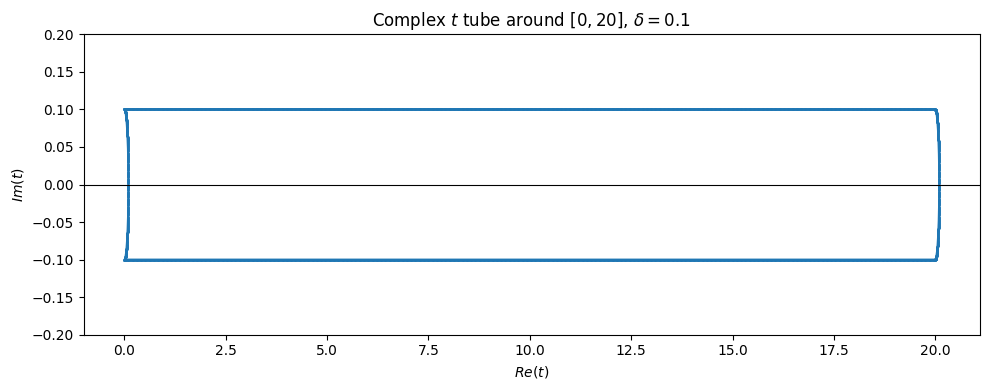

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_values_tube.real, t_values_tube.imag, ".-", markersize=2)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xlabel(r"$Re(t)$")
ax.set_ylabel(r"$Im(t)$")
ax.set_ylim([-2*delta, 2*delta])
ax.set_title(rf"Complex $t$ tube around $[0,{T:g}]$, $\delta={delta:g}$")
fig.tight_layout()
plt.show()

In [25]:
G_exact_tube = compute_exact_t(t_values_tube, wn, U, beta)
print("G_exact_tube shape:", G_exact_tube.shape)

G_exact_tube shape: (2400, 80, 2, 2)


In [26]:
wn_id = [Nw - 1, Nw - 2, Nw - 3, Nw - 4, Nw - 5]
print("Selected Matsubara indices:", wn_id)
print("Selected omegas:", wn[wn_id])

Selected Matsubara indices: [39, 38, 37, 36, 35]
Selected omegas: [-0.31415927 -0.9424778  -1.57079633 -2.19911486 -2.82743339]


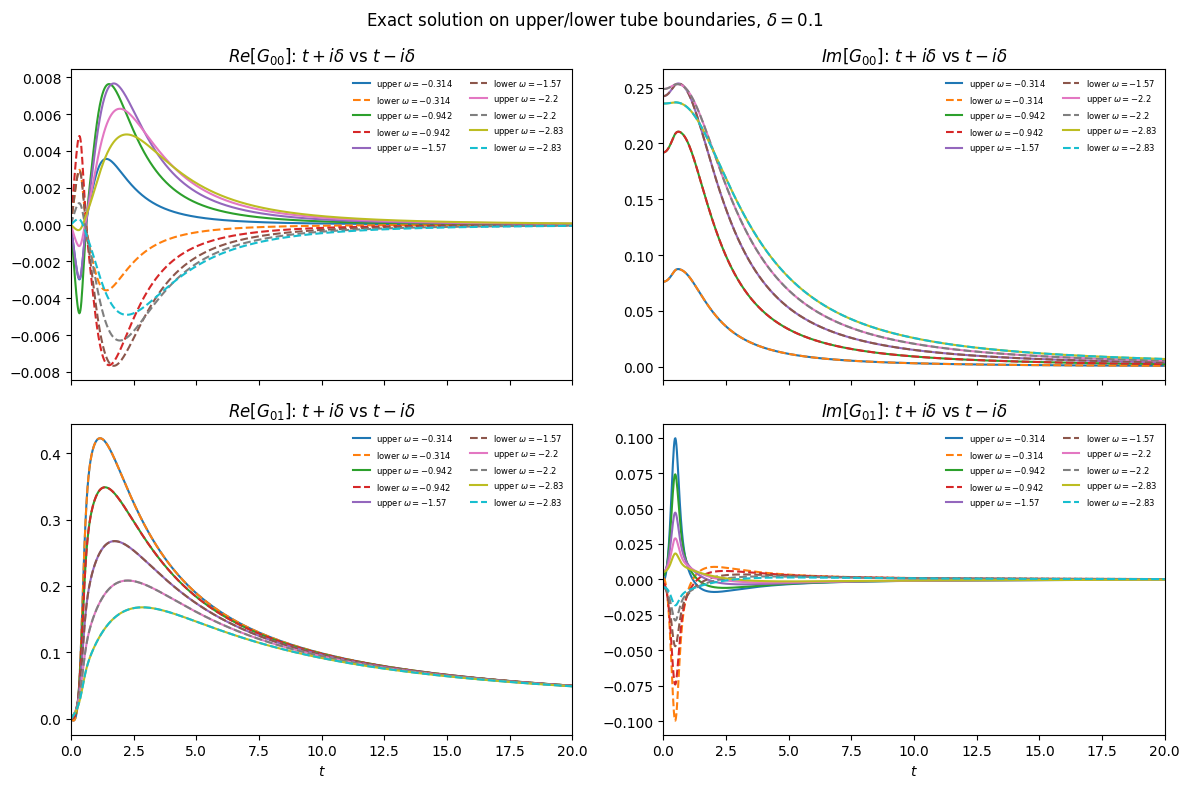

In [27]:
# Exact solution on the upper and lower boundaries of the delta tube.
t_upper = t_values_ED + 1j * delta
t_lower = t_values_ED - 1j * delta

G_exact_upper = compute_exact_t(t_upper, wn, U, beta)
G_exact_lower = compute_exact_t(t_lower, wn, U, beta)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for n in wn_id:
    axes[0, 0].plot(t_values_ED, G_exact_upper[:, n, 0, 0].real, label=rf"upper $\omega={wn[n]:.3g}$")
    axes[0, 0].plot(t_values_ED, G_exact_lower[:, n, 0, 0].real, "--", label=rf"lower $\omega={wn[n]:.3g}$")

    axes[0, 1].plot(t_values_ED, G_exact_upper[:, n, 0, 0].imag, label=rf"upper $\omega={wn[n]:.3g}$")
    axes[0, 1].plot(t_values_ED, G_exact_lower[:, n, 0, 0].imag, "--", label=rf"lower $\omega={wn[n]:.3g}$")

    axes[1, 0].plot(t_values_ED, G_exact_upper[:, n, 0, 1].real, label=rf"upper $\omega={wn[n]:.3g}$")
    axes[1, 0].plot(t_values_ED, G_exact_lower[:, n, 0, 1].real, "--", label=rf"lower $\omega={wn[n]:.3g}$")

    axes[1, 1].plot(t_values_ED, G_exact_upper[:, n, 0, 1].imag, label=rf"upper $\omega={wn[n]:.3g}$")
    axes[1, 1].plot(t_values_ED, G_exact_lower[:, n, 0, 1].imag, "--", label=rf"lower $\omega={wn[n]:.3g}$")

axes[0, 0].set_title(r"$Re[G_{00}]$: $t+i\delta$ vs $t-i\delta$")
axes[0, 1].set_title(r"$Im[G_{00}]$: $t+i\delta$ vs $t-i\delta$")
axes[1, 0].set_title(r"$Re[G_{01}]$: $t+i\delta$ vs $t-i\delta$")
axes[1, 1].set_title(r"$Im[G_{01}]$: $t+i\delta$ vs $t-i\delta$")

for ax in axes[1, :]:
    ax.set_xlabel(r"$t$")
for ax in axes.ravel():
    ax.set_xlim([0, T])
    ax.legend(frameon=False, fontsize=6, ncol=2)

fig.suptitle(rf"Exact solution on upper/lower tube boundaries, $\delta={delta:g}$")
fig.tight_layout()
plt.show()

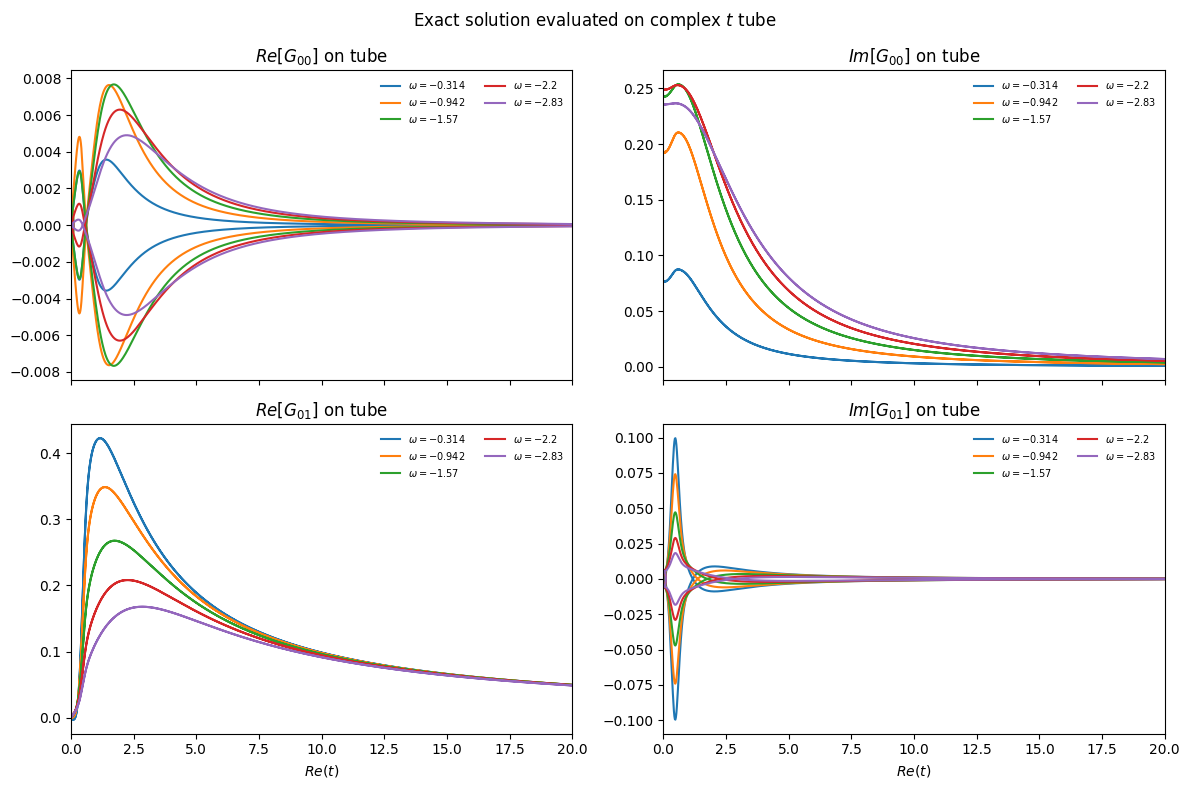

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for n in wn_id:
    axes[0, 0].plot(t_values_tube.real, G_exact_tube[:, n, 0, 0].real, label=rf"$\omega={wn[n]:.3g}$")
    axes[0, 1].plot(t_values_tube.real, G_exact_tube[:, n, 0, 0].imag, label=rf"$\omega={wn[n]:.3g}$")
    axes[1, 0].plot(t_values_tube.real, G_exact_tube[:, n, 0, 1].real, label=rf"$\omega={wn[n]:.3g}$")
    axes[1, 1].plot(t_values_tube.real, G_exact_tube[:, n, 0, 1].imag, label=rf"$\omega={wn[n]:.3g}$")

axes[0, 0].set_title(r"$Re[G_{00}]$ on tube")
axes[0, 1].set_title(r"$Im[G_{00}]$ on tube")
axes[1, 0].set_title(r"$Re[G_{01}]$ on tube")
axes[1, 1].set_title(r"$Im[G_{01}]$ on tube")

for ax in axes[1, :]:
    ax.set_xlabel(r"$Re(t)$")
for ax in axes.ravel():
    ax.set_xlim([0, T])
    ax.legend(frameon=False, fontsize=7, ncol=2)

fig.suptitle(r"Exact solution evaluated on complex $t$ tube")
fig.tight_layout()
plt.show()